## Tech Challenge 2 — Classificação de Qualidade de Vinhos

**Seções adicionadas para atender ao roteiro do Tech Challenge:**

### 1. Importação de bibliotecas e definição de variável alvo


In [ ]:
# Importação das bibliotecas

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração do estilo dos gráficos
sns.set_theme(style="whitegrid")


# Carregamento da base de dados

df = pd.read_csv("WineQT.csv")

# Visualização das primeiras linhas da base
display(df.head())


# Criação da variável alvo

# Classifica os vinhos em:
# 1 = qualidade alta (quality >= 7)
# 0 = qualidade baixa (quality < 7)
df["target"] = np.where(df["quality"] >= 7, 1, 0)

# Verificação da distribuição da variável alvo
print("Variável 'target' criada com sucesso!\n")
print(df["target"].value_counts())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


Variável 'target' criada com sucesso!

target
0    984
1    159
Name: count, dtype: int64


### 2. Análise Exploratória

#### 2.1 Dados Faltantes e Outliers

In [ ]:
# Verificação de valores faltantes

# Quantidade de valores nulos por variável
print("Valores nulos por coluna:")
print(df.isnull().sum())

# Quantidade de registros com pelo menos um valor nulo
print(f"\nTotal de linhas com valores faltantes: {df.isnull().any(axis=1).sum()}")

Valores nulos por coluna:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
target                  0
dtype: int64

Total de linhas com valores faltantes: 0


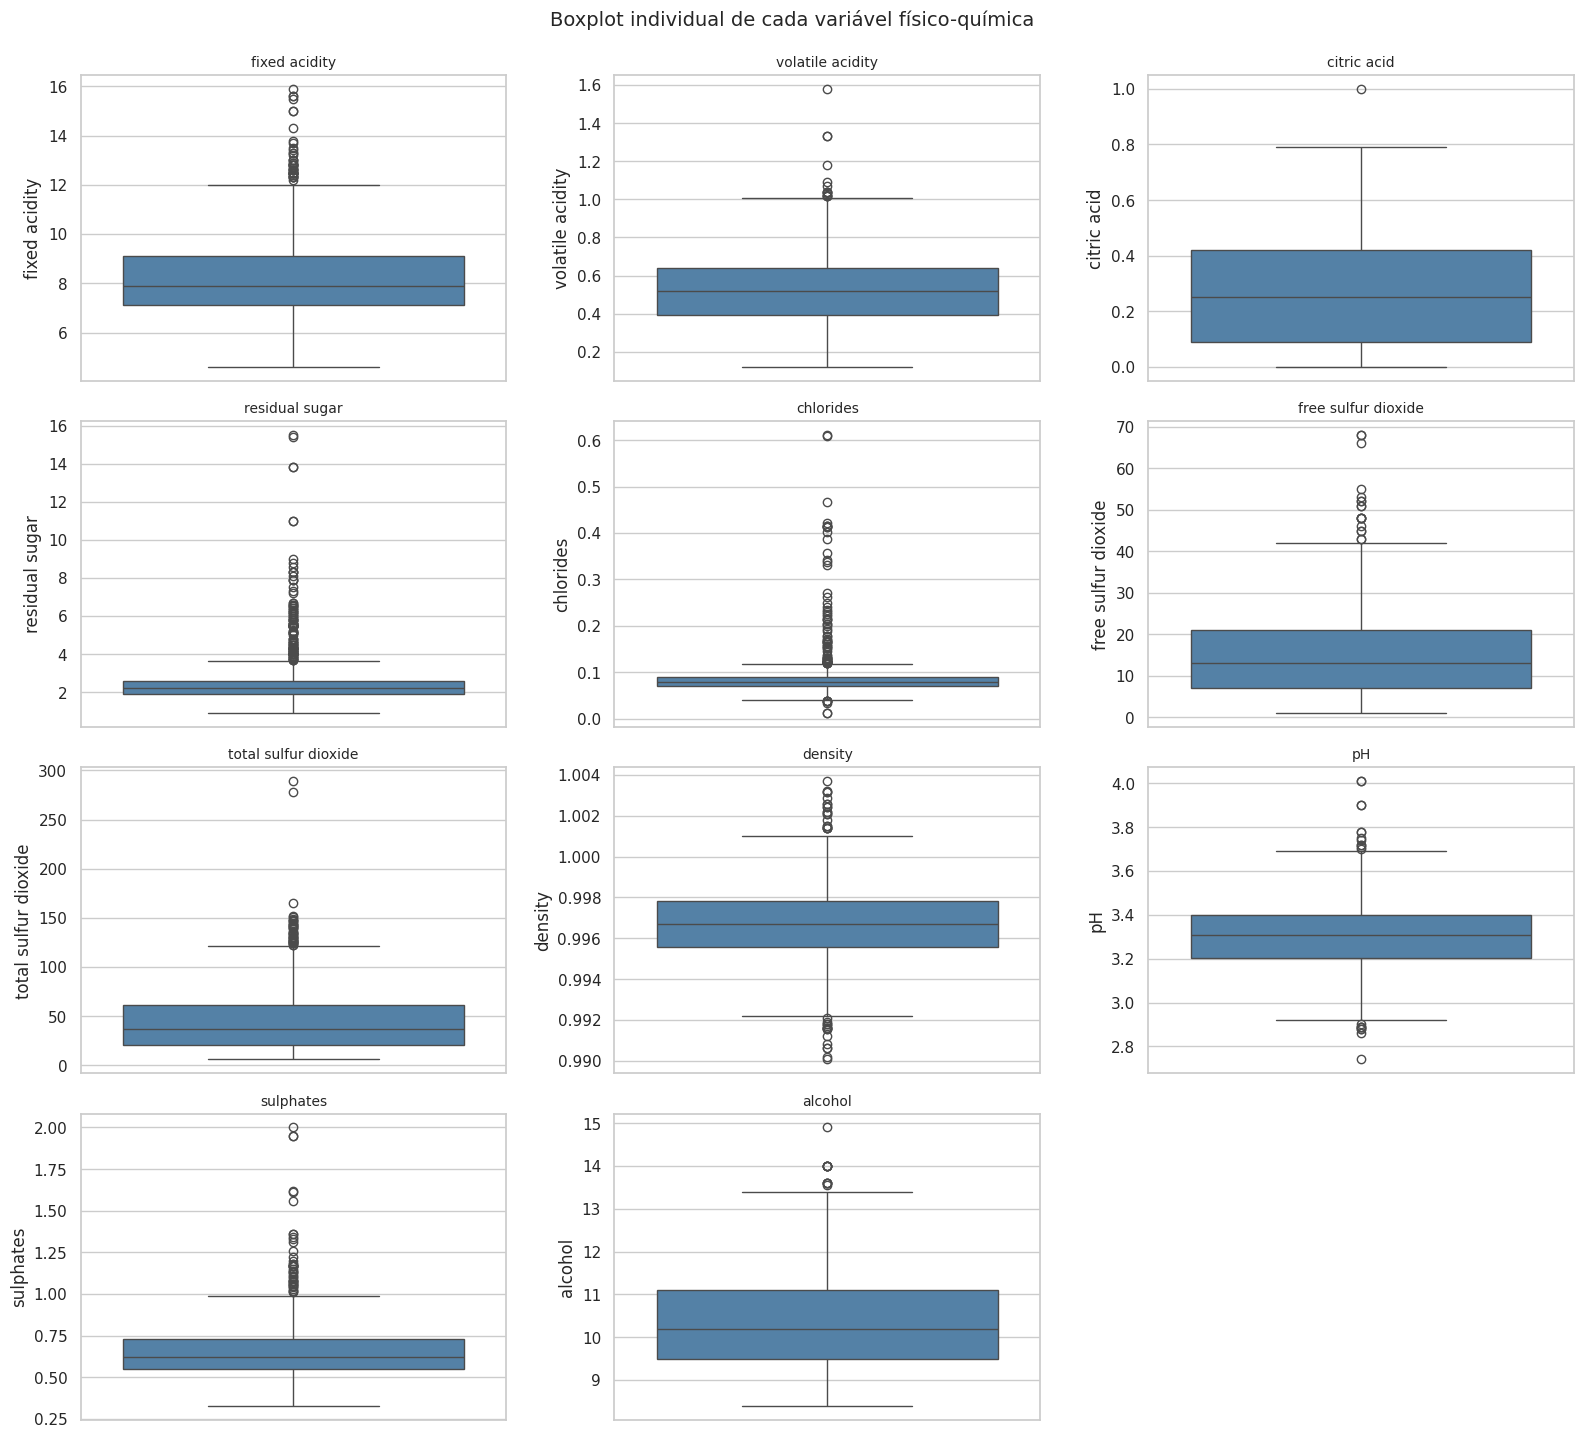

Quantidade de outliers por variável (regra IQR):
residual sugar          110
chlorides                77
fixed acidity            44
sulphates                43
total sulfur dioxide     40
density                  36
pH                       20
free sulfur dioxide      18
volatile acidity         14
alcohol                  12
citric acid               1
dtype: int64

Total de linhas do dataset: 1143


In [ ]:
# Detecção de outliers

# Seleção das variáveis numéricas
colunas_numericas = [
    c for c in df.columns
    if c not in ("Id", "quality", "target")
]

# Boxplots das variáveis numéricas
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(colunas_numericas):
    sns.boxplot(y=df[col], ax=axes[i], color="steelblue")
    axes[i].set_title(col, fontsize=10)

# Remove eixos não utilizados
for j in range(len(colunas_numericas), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.suptitle(
    "Boxplot individual de cada variável físico-química",
    y=1.02,
    fontsize=14
)
plt.show()


# Função para contagem de outliers pelo método IQR
def contar_outliers_iqr(serie):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1

    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr

    return ((serie < limite_inf) | (serie > limite_sup)).sum()


# Quantidade de outliers por variável
outliers_por_coluna = pd.Series({
    col: contar_outliers_iqr(df[col])
    for col in colunas_numericas
}).sort_values(ascending=False)

print("Quantidade de outliers por variável (regra IQR):")
print(outliers_por_coluna)

print(f"\nTotal de linhas do dataset: {len(df)}")

**Tratamento dos outliers**

As variáveis residual *sugar*, *chlorides*, *sulphates* e *total sulfur dioxide* apresentam maior quantidade de outliers. Esses valores são esperados em dados físico-químicos de vinhos e podem representar características reais de determinados lotes, não necessariamente erros de medição.

**Decisão adotada:** os outliers foram mantidos, pois não há indícios de valores inválidos e os principais modelos baseados em árvores (Random Forest, Gradient Boosting e XGBoost) são pouco sensíveis a esse tipo de observação. Para a Regressão Logística, o impacto é reduzido pela padronização dos dados com o **StandardScaler**.

#### 2.2 Matriz de Correlação

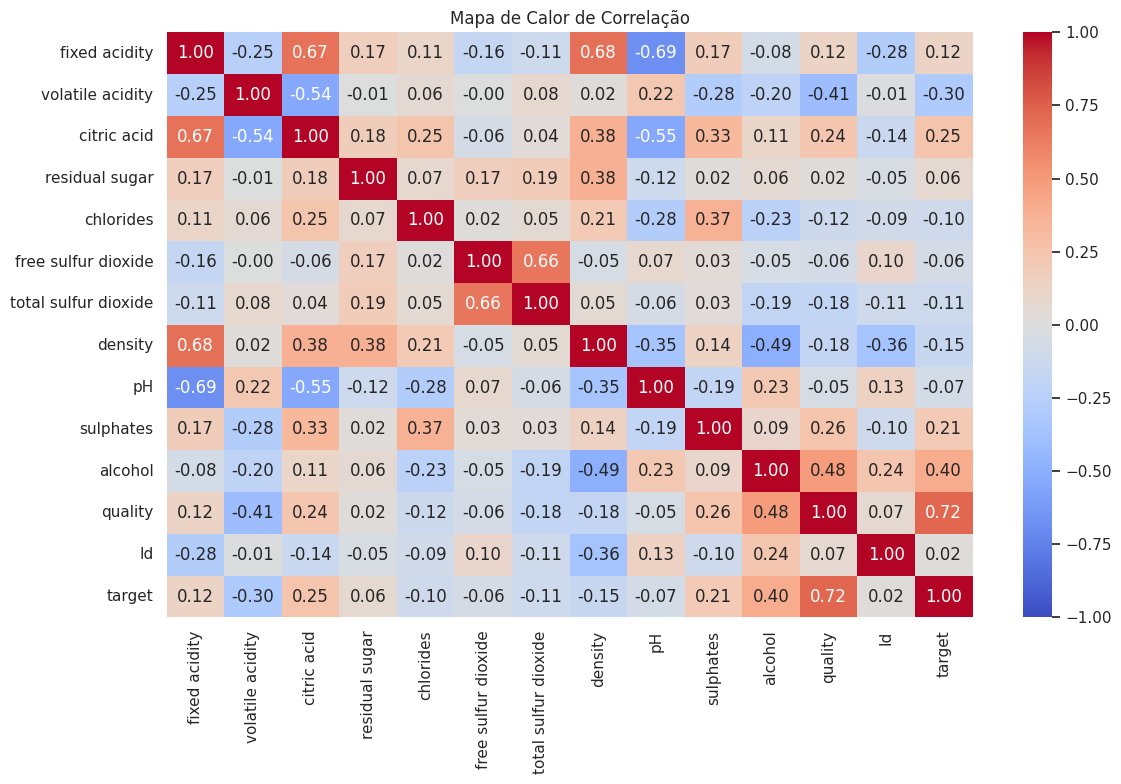

In [ ]:
# Matriz de correlação

plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1,
    center=0
)

plt.title("Mapa de Calor de Correlação")
plt.tight_layout()
plt.show()

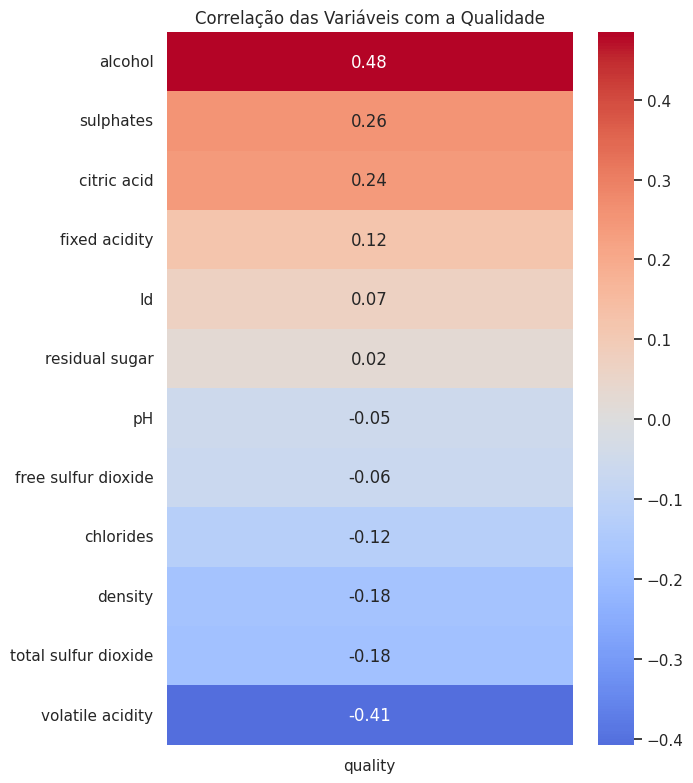

In [ ]:
# Correlação das variáveis com a qualidade

correlacao = (
    df.corr(numeric_only=True)["quality"]
      .drop(["quality", "target"])
      .sort_values(ascending=False)
)

plt.figure(figsize=(7, 8))

sns.heatmap(
    correlacao.to_frame(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    center=0,
    cbar=True
)

plt.title("Correlação das Variáveis com a Qualidade")
plt.xlabel("")
plt.ylabel("")

plt.tight_layout()
plt.show()

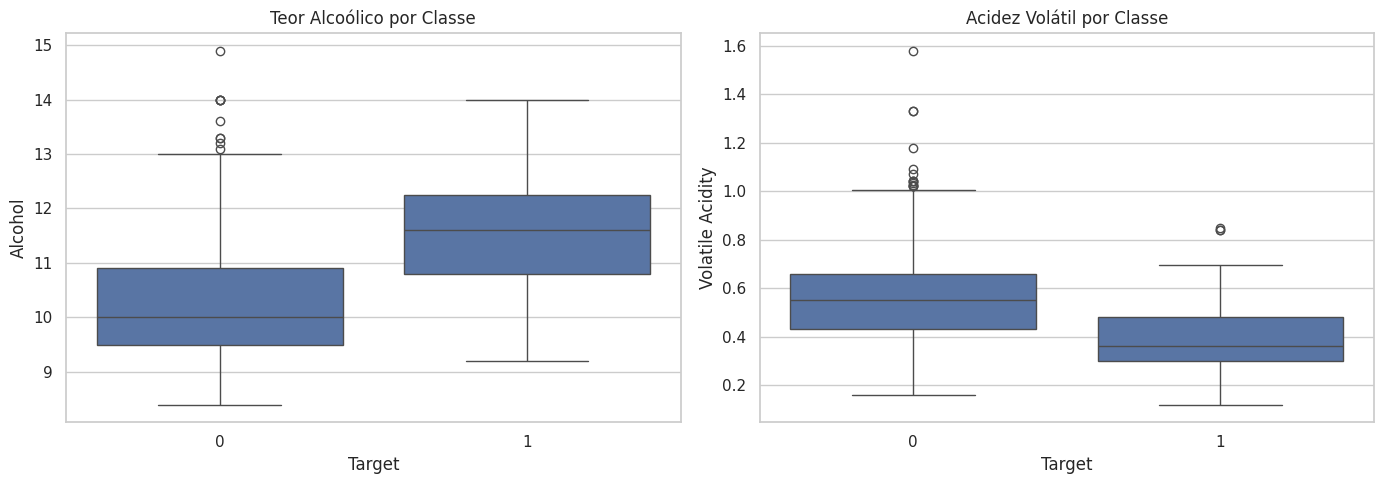

In [ ]:
# Distribuição das principais variáveis por classe

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=df,
    x="target",
    y="alcohol",
    ax=axes[0]
)
axes[0].set_title("Teor Alcoólico por Classe")
axes[0].set_xlabel("Target")
axes[0].set_ylabel("Alcohol")

sns.boxplot(
    data=df,
    x="target",
    y="volatile acidity",
    ax=axes[1]
)
axes[1].set_title("Acidez Volátil por Classe")
axes[1].set_xlabel("Target")
axes[1].set_ylabel("Volatile Acidity")

plt.tight_layout()
plt.show()

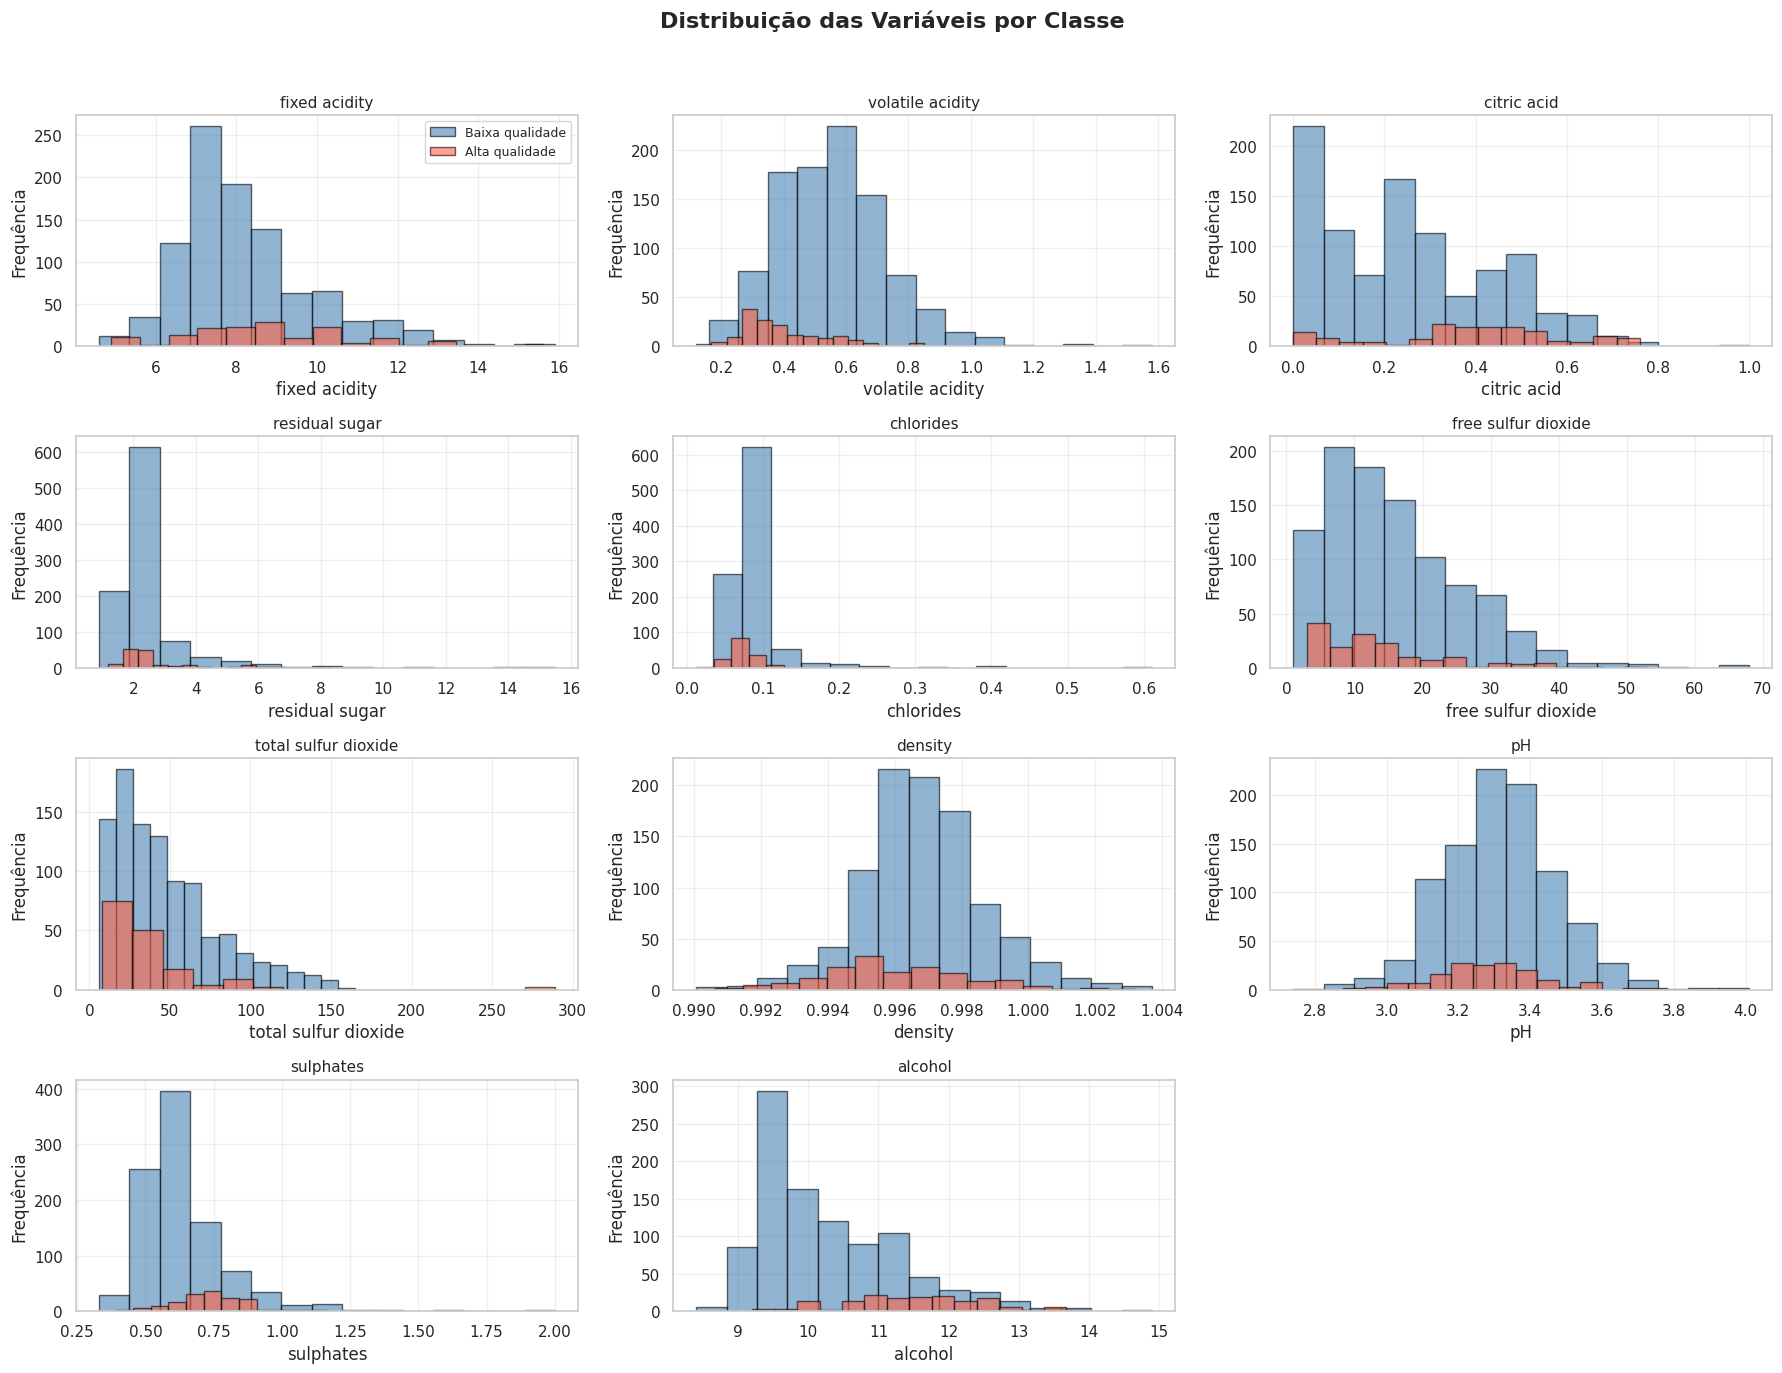

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 100

# Distribuição das variáveis por classe

colunas = [c for c in df.columns if c not in ["Id", "quality", "target"]]

df_high = df[df["target"] == 1]
df_low = df[df["target"] == 0]

fig, axes = plt.subplots(4, 3, figsize=(18, 14), dpi=100)
axes = axes.flatten()

for i, col in enumerate(colunas):

    axes[i].hist(
        df_low[col],
        bins=15,
        alpha=0.6,
        color="steelblue",
        edgecolor="black",
        label="Baixa qualidade"
    )

    axes[i].hist(
        df_high[col],
        bins=15,
        alpha=0.6,
        color="tomato",
        edgecolor="black",
        label="Alta qualidade"
    )

    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequência")
    axes[i].grid(alpha=0.3)

# Remove eixos vazios
for j in range(len(colunas), len(axes)):
    axes[j].axis("off")

# Legenda apenas no primeiro gráfico
axes[0].legend(
    loc="upper right",
    fontsize=9,
    frameon=True
)

# Título geral
fig.suptitle(
    "Distribuição das Variáveis por Classe",
    fontsize=16,
    fontweight="bold"
)

# Ajusta o layout deixando espaço para o título
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

##### 2.2.1 Interpretação das correlações observadas

A análise de correlação mostra que o **teor alcoólico (0,48)** apresenta a maior associação positiva com a qualidade do vinho, indicando que vinhos com maior teor alcoólico tendem a receber melhores avaliações. Em contrapartida, a **acidez volátil (-0,41)** possui a maior correlação negativa, sugerindo que valores elevados dessa variável estão relacionados à redução da qualidade.

Além disso, **sulfatos (0,26)** e **ácido cítrico (0,24)** apresentam correlação positiva moderada, enquanto **densidade (-0,18)** e **dióxido de enxofre total (-0,18)** apresentam correlação negativa com a qualidade..

### 3. Feature Engineering

Criamos algumas variáveis derivadas com justificativa físico-química, para avaliar se elas
agregam informação além das variáveis originais. Elas entram no `X` junto com as demais e sua
importância será avaliada mais adiante, então dá pra ver depois se valeram a pena.

In [ ]:
# Criação de novas variáveis

# Soma da acidez fixa e volátil
df["acidez_total"] = df["fixed acidity"] + df["volatile acidity"]

# Proporção entre SO₂ livre e SO₂ total
df["razao_so2_livre"] = (
    df["free sulfur dioxide"] /
    df["total sulfur dioxide"].replace(0, np.nan)
).fillna(0)

# Relação entre teor alcoólico e densidade
df["alcool_por_densidade"] = df["alcohol"] / df["density"]

# Resumo das novas variáveis
print("Novas variáveis criadas:")
print("- acidez_total")
print("- razao_so2_livre")
print("- alcool_por_densidade")

display(
    df[
        ["acidez_total", "razao_so2_livre", "alcool_por_densidade"]
    ].describe()
)

Novas variáveis criadas:
- acidez_total
- razao_so2_livre
- alcool_por_densidade


,acidez_total,razao_so2_livre,alcool_por_densidade
count,1143.000000,1143.000000,1143.000000
mean,8.842450,0.380418,10.477443
std,1.711413,0.154112,1.096987
min,5.120000,0.022727,8.393285
25%,7.690000,0.257473,9.536716
50%,8.460000,0.375000,10.208780
75%,9.660000,0.478261,11.160139
max,16.285000,0.857143,14.935846


### 4. Divisão Treino (70%) / Validação (15%) / Teste (15%)

Os dados foram separados em treino (70%), validação (15%) e teste (15%). O conjunto de validação é utilizado para otimizar os modelos, enquanto o conjunto de teste é utilizado apenas na avaliação final.

In [ ]:
from sklearn.model_selection import train_test_split

# Separação das variáveis preditoras e da variável alvo

X = df.drop(["quality", "Id", "target"], axis=1)
y = df["target"]


# Divisão dos dados em treino, validação e teste

# 85% para treino e validação | 15% para teste
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=37,
    stratify=y
)

# Separação do conjunto de validação
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=(0.15 / 0.85),
    random_state=37,
    stratify=y_train_val
)

# Quantidade de amostras em cada conjunto
print(f"Treino:     {X_train.shape[0]} amostras")
print(f"Validação:  {X_val.shape[0]} amostras")
print(f"Teste:      {X_test.shape[0]} amostras")

Treino:     799 amostras
Validação:  172 amostras
Teste:      172 amostras


###5. Modelos

#### 5.1 Baseline (Modelo "Bobo")

Comparação realizada antes de modelo real, para compreensão do quanto a acurácia
isolada pode enganar neste dataset devido ao desbalanceamento.

Relatório de classificação - Modelo Baseline
              precision    recall  f1-score   support

           0       0.86      1.00      0.93       148
           1       0.00      0.00      0.00        24

    accuracy                           0.86       172
   macro avg       0.43      0.50      0.46       172
weighted avg       0.74      0.86      0.80       172



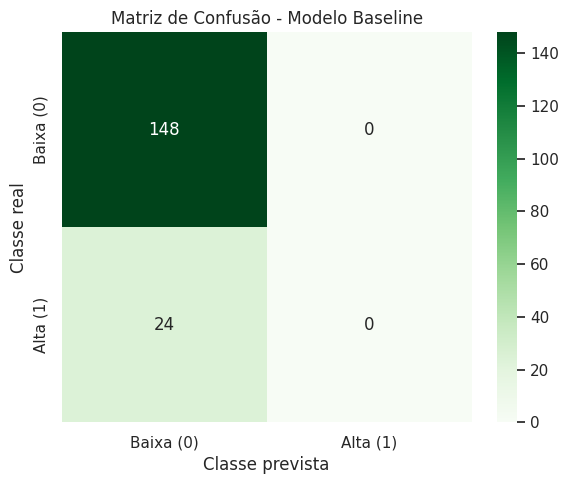

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Modelo baseline

# Criação e treinamento do modelo baseline
modelo_bobo = DummyClassifier(strategy="most_frequent")
modelo_bobo.fit(X_train, y_train)

# Previsões no conjunto de teste
y_pred_bobo = modelo_bobo.predict(X_test)

# Avaliação do modelo
print("Relatório de classificação - Modelo Baseline")
print(classification_report(y_test, y_pred_bobo, zero_division=0))

# Matriz de confusão
cm_bobo = confusion_matrix(y_test, y_pred_bobo)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_bobo,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Baixa (0)", "Alta (1)"],
    yticklabels=["Baixa (0)", "Alta (1)"]
)

plt.title("Matriz de Confusão - Modelo Baseline")
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")

plt.tight_layout()
plt.show()


#### 5.2 Qual estratégia de balanceamento usar?

Foram avaliadas três estratégias de balanceamento por meio de validação cruzada estratificada no conjunto de treino. A comparação foi realizada utilizando a métrica **Average Precision (AUC-PR)**, por ser mais apropriada que a acurácia em problemas com classes desbalanceadas. Os conjuntos de validação e teste foram preservados para as etapas posteriores.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Avaliação de estratégias para balanceamento das classes

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=37
)

# Estratégias avaliadas
estrategias = {
    "RandomOverSampler": ImbPipeline([
        ("sampler", RandomOverSampler(random_state=37)),
        ("modelo", RandomForestClassifier(n_estimators=100, random_state=37))
    ]),

    "SMOTE": ImbPipeline([
        ("sampler", SMOTE(random_state=37)),
        ("modelo", RandomForestClassifier(n_estimators=100, random_state=37))
    ]),

    "Class Weight": RandomForestClassifier(
        n_estimators=100,
        random_state=37,
        class_weight="balanced"
    ),
}

# Validação cruzada
resultados_estrategias = {}

for nome, pipeline in estrategias.items():

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="average_precision"
    )

    resultados_estrategias[nome] = scores

    print(
        f"{nome:20s} | "
        f"AUC-PR: {scores.mean():.3f} ± {scores.std():.3f}"
    )

# Melhor estratégia
melhor_estrategia = max(
    resultados_estrategias,
    key=lambda k: resultados_estrategias[k].mean()
)

print(f"\nMelhor estratégia: {melhor_estrategia}")

RandomOverSampler    | AUC-PR: 0.677 ± 0.037
SMOTE                | AUC-PR: 0.642 ± 0.062
Class Weight         | AUC-PR: 0.645 ± 0.061

Melhor estratégia: RandomOverSampler


#### 5.3 Comparação de Modelos via Validação Cruzada

Agora comparamos famílias de modelos usando a estratégia de balanceamento vencedora da etapa
anterior.

In [ ]:
# Importação dos modelos

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier


# Criação dos pipelines

def montar_pipeline(modelo_base, usa_scaler=False):

    passos = []

    if melhor_estrategia == "RandomOverSampler":
        passos.append(("sampler", RandomOverSampler(random_state=37)))

    elif melhor_estrategia == "SMOTE":
        passos.append(("sampler", SMOTE(random_state=37)))

    if usa_scaler:
        passos.append(("scaler", StandardScaler()))

    passos.append(("modelo", modelo_base))

    return (
        ImbPipeline(passos)
        if any(p[0] == "sampler" for p in passos)
        else Pipeline(passos)
    )


# Definição dos modelos

class_weight_kw = (
    {"class_weight": "balanced"}
    if melhor_estrategia == "class_weight_balanced"
    else {}
)

modelos_candidatos = {
    'RandomForest': montar_pipeline(
        RandomForestClassifier(n_estimators=100, random_state=37, **class_weight_kw)
    ),
    'LogisticRegression': montar_pipeline(
        LogisticRegression(random_state=37, max_iter=1000, **class_weight_kw), usa_scaler=True
    ),
    'GradientBoosting': montar_pipeline(
        GradientBoostingClassifier(random_state=37)
    ),
    'XGBoost': montar_pipeline(
        XGBClassifier(random_state=37, eval_metric='logloss',
                       scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()
                       if melhor_estrategia == 'class_weight_balanced' else 1)
    )
}


# Avaliação dos modelos

print("Comparação dos modelos (AUC-PR):\n")

resultados_modelos = {}

for nome, pipeline in modelos_candidatos.items():

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="average_precision"
    )

    resultados_modelos[nome] = scores

    print(f"{nome:20s} {scores.mean():.3f} \u00b1 {scores.std():.3f}")


# Seleção do melhor modelo

melhor_modelo_nome = max(
    resultados_modelos,
    key=lambda k: resultados_modelos[k].mean()
)

print(f"\nMelhor modelo: {melhor_modelo_nome}")

Comparação dos modelos (AUC-PR):

RandomForest         0.677 ± 0.037
LogisticRegression   0.520 ± 0.055
GradientBoosting     0.592 ± 0.074
XGBoost              0.604 ± 0.054

Melhor modelo: RandomForest


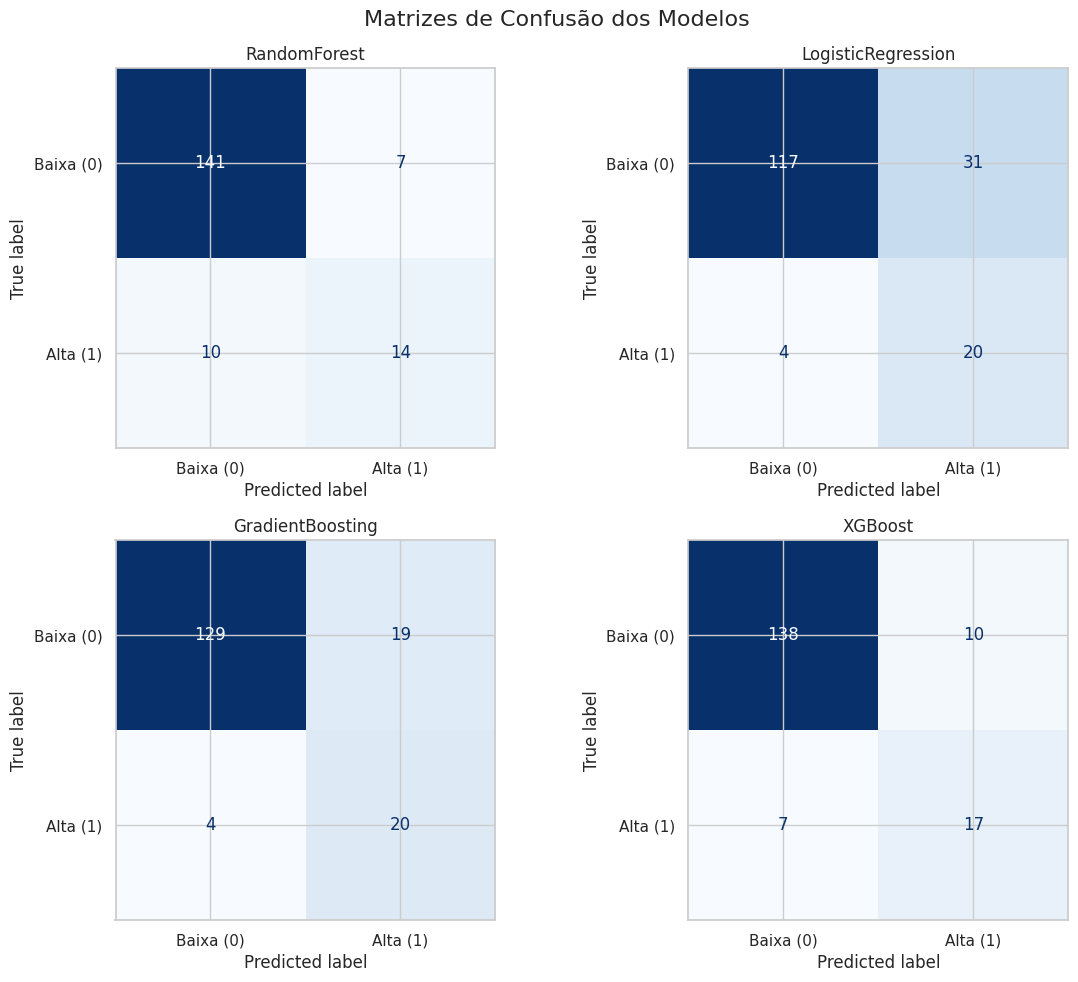

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Avaliação dos modelos no conjunto de teste

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (nome, pipeline) in zip(axes, modelos_candidatos.items()):

    # Treinamento
    pipeline.fit(X_train, y_train)

    # Previsões
    y_pred = pipeline.predict(X_test)

    # Matriz de confusão
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Baixa (0)", "Alta (1)"]
    )

    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(nome)

plt.suptitle("Matrizes de Confusão dos Modelos", fontsize=16)
plt.tight_layout()
plt.show()

####5.4 Interpretação dos resultados

Os modelos foram comparados utilizando validação cruzada e a métrica AUC-PR (average precision). Entre os modelos avaliados, o Random Forest apresentou o melhor desempenho médio, sendo selecionado para a etapa de ajuste de hiperparâmetros.

#### 5.5 Ajuste de Hiperparâmetros (GridSearchCV)

Após a comparação dos modelos, foi realizado o ajuste de hiperparâmetros apenas do **Random Forest**, por ter apresentado o melhor desempenho na etapa anterior.

Para essa otimização, foi utilizado o GridSearchCV, mantendo a mesma estratégia de validação cruzada (StratifiedKFold) e a mesma métrica de avaliação (average_precision).

Foram avaliadas diferentes combinações dos seguintes hiperparâmetros:

n_estimators: 100, 200 e 300;
max_depth: None, 8 e 12;
min_samples_leaf: 1, 2 e 4.

A melhor configuração encontrada foi:

n_estimators: 200;
max_depth: 8;
min_samples_leaf: 1.

O modelo final foi então treinado utilizando esses hiperparâmetros no conjunto de treinamento.

In [ ]:
from sklearn.model_selection import GridSearchCV

grid = {
    "modelo__n_estimators": [100, 200, 300],
    "modelo__max_depth": [None, 8, 12],
    "modelo__min_samples_leaf": [1, 2, 4],
}

busca = GridSearchCV(
    estimator=modelos_candidatos["RandomForest"],
    param_grid=grid,
    cv=cv,
    scoring="average_precision",
    n_jobs=-1,
)

busca.fit(X_train, y_train)

print("Melhores parâmetros:")
print(busca.best_params_)
print(f"Melhor AUC-PR (CV): {busca.best_score_:.3f}")

modelo_final = busca.best_estimator_

print("\nModelo final treinado com todo o conjunto de treino.")

Melhores parâmetros:
{'modelo__max_depth': 8, 'modelo__min_samples_leaf': 1, 'modelo__n_estimators': 200}
Melhor AUC-PR (CV): 0.692

Modelo final treinado com todo o conjunto de treino.


#### 5.6 Calibração de Limiar — usando o conjunto de VALIDAÇÃO

Após o treinamento do modelo, foi utilizada a curva Precision-Recall no conjunto de validação para analisar o desempenho do classificador em diferentes limiares de decisão.

Como o modelo retorna probabilidades para cada observação, é possível definir diferentes limiares para classificar um vinho como de alta qualidade.

#####5.6.1 Curva Precision-Recall no conjunto de validação

AUC-PR (validação): 0.767


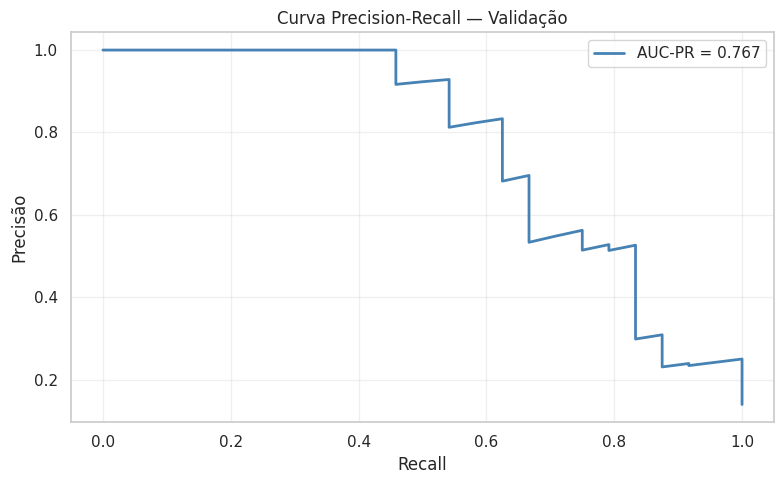

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Probabilidades previstas para a classe positiva
y_probs_val = modelo_final.predict_proba(X_val)[:, 1]

# Curva Precision-Recall
precision_val, recall_val, thresholds_val = precision_recall_curve(
    y_val,
    y_probs_val
)

# Área sob a curva Precision-Recall
auc_pr_val = average_precision_score(y_val, y_probs_val)

print(f"AUC-PR (validação): {auc_pr_val:.3f}")

# Gráfico
plt.figure(figsize=(8, 5))

plt.plot(
    recall_val,
    precision_val,
    color="steelblue",
    linewidth=2,
    label=f"AUC-PR = {auc_pr_val:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precisão")
plt.title("Curva Precision-Recall — Validação")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

#####5.6.2 Definição dos limiares de decisão

In [ ]:
# Função para selecionar limiares a partir da curva Precision-Recall

def escolher_limiar(
    precision,
    recall,
    thresholds,
    min_recall=None,
    min_precision=None
):
    candidatos = []

    for p, r, t in zip(precision[:-1], recall[:-1], thresholds):

        if min_recall is not None and r < min_recall:
            continue

        if min_precision is not None and p < min_precision:
            continue

        candidatos.append((t, p, r))

    if not candidatos:
        return None

    # Triagem: maximizar recall mantendo precisão mínima
    if min_precision is not None:
        return max(candidatos, key=lambda x: x[2])

    # Certificação: maximizar precisão mantendo recall mínimo
    return max(candidatos, key=lambda x: x[1])


# Critérios de negócio

limiar_certificacao = escolher_limiar(
    precision_val,
    recall_val,
    thresholds_val,
    min_recall=0.30
)

limiar_triagem = escolher_limiar(
    precision_val,
    recall_val,
    thresholds_val,
    min_precision=0.50
)

# Limiares finais

limiar_alta = (
    limiar_certificacao[0]
    if limiar_certificacao is not None
    else 0.725
)

limiar_potencial = (
    limiar_triagem[0]
    if limiar_triagem is not None
    else 0.470
)

print("Limiares definidos a partir do conjunto de validação:\n")

print(
    f"Alta qualidade (certificação): "
    f"{limiar_alta:.3f}"
)

print(
    f"Potencialmente alta qualidade (triagem): "
    f"{limiar_potencial:.3f}"
)

Limiares definidos a partir do conjunto de validação:

Alta qualidade (certificação): 0.853
Potencialmente alta qualidade (triagem): 0.475


#####5.6.3 Curva ROC com os limiares selecionados

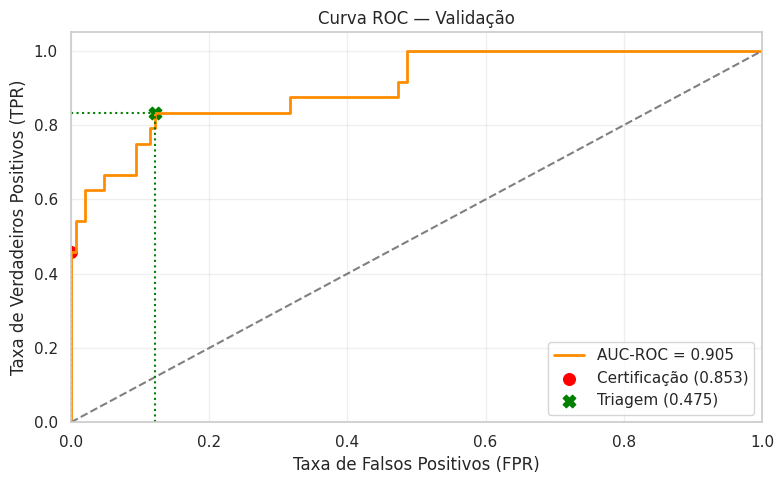

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# Curva ROC

fpr_val, tpr_val, thresholds_roc = roc_curve(
    y_val,
    y_probs_val
)

auc_roc_val = roc_auc_score(
    y_val,
    y_probs_val
)

plt.figure(figsize=(8, 5))

plt.plot(
    fpr_val,
    tpr_val,
    color="darkorange",
    linewidth=2,
    label=f"AUC-ROC = {auc_roc_val:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray"
)

# Limiar de certificação

idx_alta = np.argmin(np.abs(thresholds_roc - limiar_alta))

plt.scatter(
    fpr_val[idx_alta],
    tpr_val[idx_alta],
    color="red",
    s=70,
    label=f"Certificação ({limiar_alta:.3f})"
)

plt.vlines(
    fpr_val[idx_alta],
    0,
    tpr_val[idx_alta],
    colors="red",
    linestyles=":"
)

plt.hlines(
    tpr_val[idx_alta],
    0,
    fpr_val[idx_alta],
    colors="red",
    linestyles=":"
)

# Limiar de triagem

idx_pot = np.argmin(np.abs(thresholds_roc - limiar_potencial))

plt.scatter(
    fpr_val[idx_pot],
    tpr_val[idx_pot],
    color="green",
    marker="X",
    s=80,
    label=f"Triagem ({limiar_potencial:.3f})"
)

plt.vlines(
    fpr_val[idx_pot],
    0,
    tpr_val[idx_pot],
    colors="green",
    linestyles=":"
)

plt.hlines(
    tpr_val[idx_pot],
    0,
    fpr_val[idx_pot],
    colors="green",
    linestyles=":"
)

plt.xlim(0, 1)
plt.ylim(0, 1.05)

plt.xlabel("Taxa de Falsos Positivos (FPR)")
plt.ylabel("Taxa de Verdadeiros Positivos (TPR)")
plt.title("Curva ROC — Validação")

plt.grid(alpha=0.3)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

#### 5.7 Avaliação final com conjunto de teste

Agora aplicamos o modelo final e os limiares (definidos na validação) ao
conjunto de teste.

5.7.1 Limiar de centificação

Relatório de Classificação — Teste (RandomForest | limiar = 0.853)

              precision    recall  f1-score   support

           0       0.91      0.99      0.95       148
           1       0.91      0.42      0.57        24

    accuracy                           0.91       172
   macro avg       0.91      0.70      0.76       172
weighted avg       0.91      0.91      0.90       172



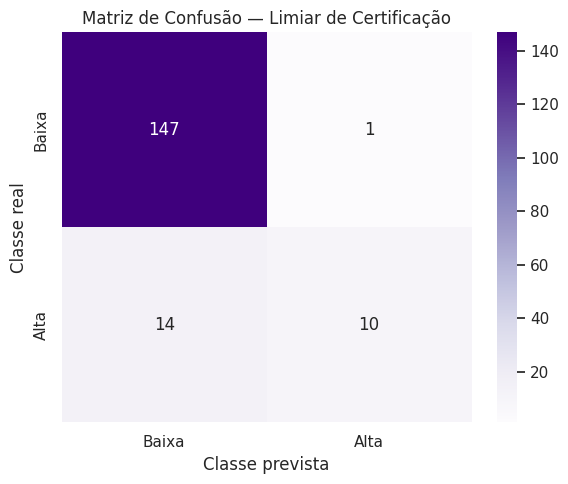

AUC-PR (teste): 0.768


In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score
)

import seaborn as sns
import matplotlib.pyplot as plt

# Probabilidades previstas no conjunto de teste
y_probs_test = modelo_final.predict_proba(X_test)[:, 1]

# Classificação usando o limiar de certificação
y_pred_alta = (y_probs_test >= limiar_alta).astype(int)

print(
    f"Relatório de Classificação — Teste "
    f"({melhor_modelo_nome} | limiar = {limiar_alta:.3f})\n"
)

print(classification_report(y_test, y_pred_alta))

# Matriz de confusão

cm = confusion_matrix(y_test, y_pred_alta)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["Baixa", "Alta"],
    yticklabels=["Baixa", "Alta"]
)

plt.xlabel("Classe prevista")
plt.ylabel("Classe real")
plt.title("Matriz de Confusão — Limiar de Certificação")

plt.tight_layout()
plt.show()

# AUC-PR final (avaliada apenas no teste)

precision_test, recall_test, _ = precision_recall_curve(
    y_test,
    y_probs_test
)

auc_pr_test = average_precision_score(
    y_test,
    y_probs_test
)

print(f"AUC-PR (teste): {auc_pr_test:.3f}")

5.7.2 Limiar de triagem

Relatório de Classificação — Teste (RandomForest | limiar = 0.475)

              precision    recall  f1-score   support

           0       0.96      0.91      0.93       148
           1       0.56      0.75      0.64        24

    accuracy                           0.88       172
   macro avg       0.76      0.83      0.79       172
weighted avg       0.90      0.88      0.89       172



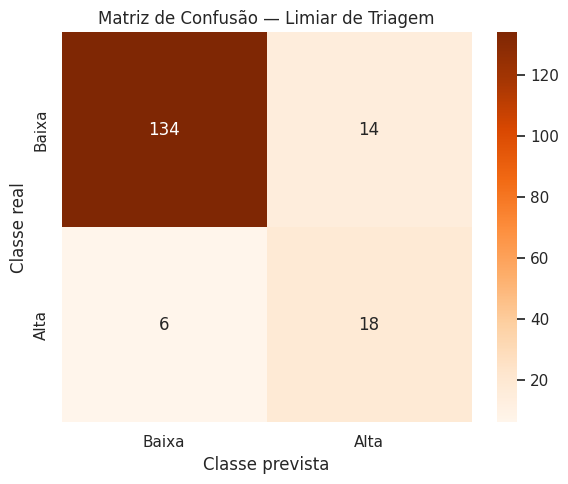

In [ ]:
# Classificação usando o limiar de triagem

y_pred_triagem = (
    y_probs_test >= limiar_potencial
).astype(int)

print(
    f"Relatório de Classificação — Teste "
    f"({melhor_modelo_nome} | limiar = {limiar_potencial:.3f})\n"
)

print(classification_report(y_test, y_pred_triagem))

cm = confusion_matrix(
    y_test,
    y_pred_triagem
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Baixa", "Alta"],
    yticklabels=["Baixa", "Alta"]
)

plt.xlabel("Classe prevista")
plt.ylabel("Classe real")
plt.title("Matriz de Confusão — Limiar de Triagem")

plt.tight_layout()
plt.show()

5.7.3 Curvas Precision-Recall e ROC no conjunto de teste

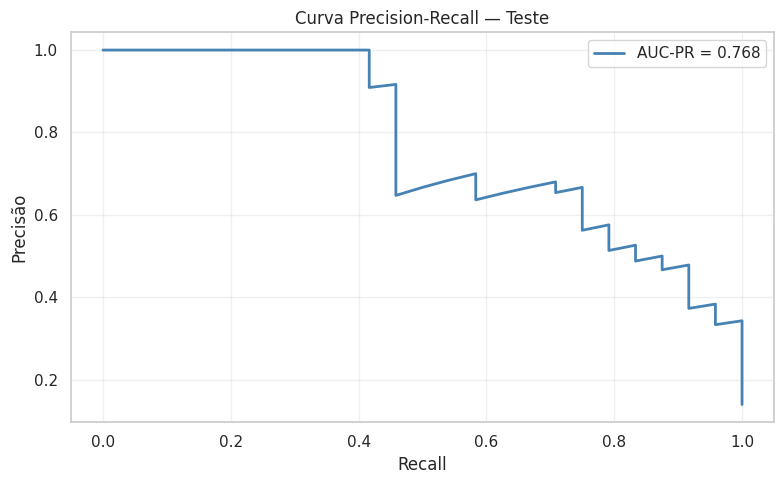

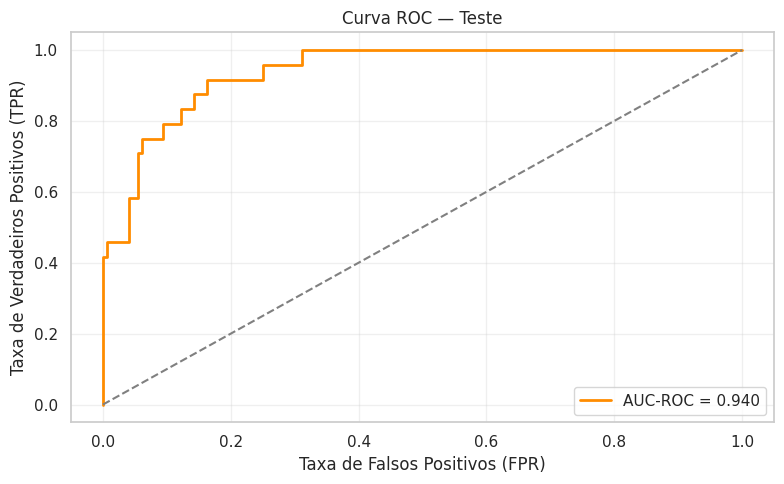

In [ ]:
from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

# Curva Precision-Recall

plt.figure(figsize=(8,5))

plt.plot(
    recall_test,
    precision_test,
    color="steelblue",
    linewidth=2,
    label=f"AUC-PR = {auc_pr_test:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precisão")
plt.title("Curva Precision-Recall — Teste")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


# Curva ROC

fpr_test, tpr_test, _ = roc_curve(
    y_test,
    y_probs_test
)

auc_roc_test = roc_auc_score(
    y_test,
    y_probs_test
)

plt.figure(figsize=(8,5))

plt.plot(
    fpr_test,
    tpr_test,
    color="darkorange",
    linewidth=2,
    label=f"AUC-ROC = {auc_roc_test:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--",
    color="gray"
)

plt.xlabel("Taxa de Falsos Positivos (FPR)")
plt.ylabel("Taxa de Verdadeiros Positivos (TPR)")
plt.title("Curva ROC — Teste")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

#### 5.8 Classificação em camadas e exportação para Excel (.xlsx)

Na etapa final, o modelo foi aplicado ao conjunto de teste utilizando os limiares definidos na etapa de validação. Com base nas probabilidades previstas, cada vinho foi classificado em uma das seguintes categorias:

Alta qualidade: vinhos com probabilidade superior ao limiar de certificação;
Potencialmente alta qualidade: vinhos com probabilidade entre o limiar de triagem e o limiar de certificação;
Comum: vinhos com probabilidade inferior ao limiar de triagem.

Por fim, os resultados foram exportados para um arquivo Excel contendo uma aba para cada categoria, facilitando a análise e a priorização dos vinhos para avaliação humana.

In [ ]:
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

# Separação das classes
df_alta = resultados[resultados["classificacao"] == "alta qualidade"]
df_pot = resultados[resultados["classificacao"] == "potencialmente alta qualidade"]
df_com = resultados[resultados["classificacao"] == "comum"]

# Estilos
VERDE_FILL = PatternFill("solid", start_color="C6EFCE")
VERDE_FONT = Font(color="276221", name="Arial", size=10)

LARANJA_FILL = PatternFill("solid", start_color="FFDFA0")
LARANJA_FONT = Font(color="7B4F00", name="Arial", size=10)

CINZA_FILL = PatternFill("solid", start_color="F1F1F1")
CINZA_FONT = Font(color="555555", name="Arial", size=10)

HEADER_FILL = PatternFill("solid", start_color="2E4057")
HEADER_FONT = Font(color="FFFFFF", bold=True, name="Arial", size=10)

thin = Side(style="thin", color="CCCCCC")
border = Border(left=thin, right=thin, top=thin, bottom=thin)

colunas = list(resultados.columns)

# Função para escrever cada aba
def escrever_aba(ws, df, fill, font):

    # Cabeçalho
    for c, col in enumerate(colunas, start=1):
        cell = ws.cell(row=1, column=c, value=col)
        cell.font = HEADER_FONT
        cell.fill = HEADER_FILL
        cell.alignment = Alignment(
            horizontal="center",
            vertical="center",
            wrap_text=True
        )
        cell.border = border

    ws.row_dimensions[1].height = 30

    # Dados
    for r, (_, row) in enumerate(df.iterrows(), start=2):
        for c, col in enumerate(colunas, start=1):
            cell = ws.cell(row=r, column=c, value=row[col])
            cell.font = font
            cell.fill = fill
            cell.border = border

    # Largura das colunas
    for c, col in enumerate(colunas, start=1):
        letra = get_column_letter(c)
        ws.column_dimensions[letra].width = max(15, len(str(col)) + 3)

# Criação do arquivo
wb = Workbook()
wb.remove(wb.active)

ws_alta = wb.create_sheet("Alta Qualidade")
escrever_aba(ws_alta, df_alta, VERDE_FILL, VERDE_FONT)

ws_pot = wb.create_sheet("Potencialmente Alta")
escrever_aba(ws_pot, df_pot, LARANJA_FILL, LARANJA_FONT)

ws_com = wb.create_sheet("Comum")
escrever_aba(ws_com, df_com, CINZA_FILL, CINZA_FONT)

# Salvar Excel
wb.save("classificacao_vinhos_teste.xlsx")

print("Arquivo 'classificacao_vinhos_teste.xlsx' salvo com sucesso.")

Arquivo 'classificacao_vinhos_teste.xlsx' salvo com sucesso.


### 6. Interpretação dos resultados

Aqui respondemos à pergunta do desafio: **quais variáveis mais influenciam a qualidade do
vinho, segundo o modelo, e o que isso sugere para o processo produtivo?**

alcool_por_densidade    0.145119
alcohol                 0.122980
citric acid             0.116033
volatile acidity        0.099658
sulphates               0.098150
acidez_total            0.058058
chlorides               0.056624
fixed acidity           0.053680
total sulfur dioxide    0.053427
density                 0.046920
razao_so2_livre         0.045855
pH                      0.037861
residual sugar          0.034098
free sulfur dioxide     0.031539
dtype: float64


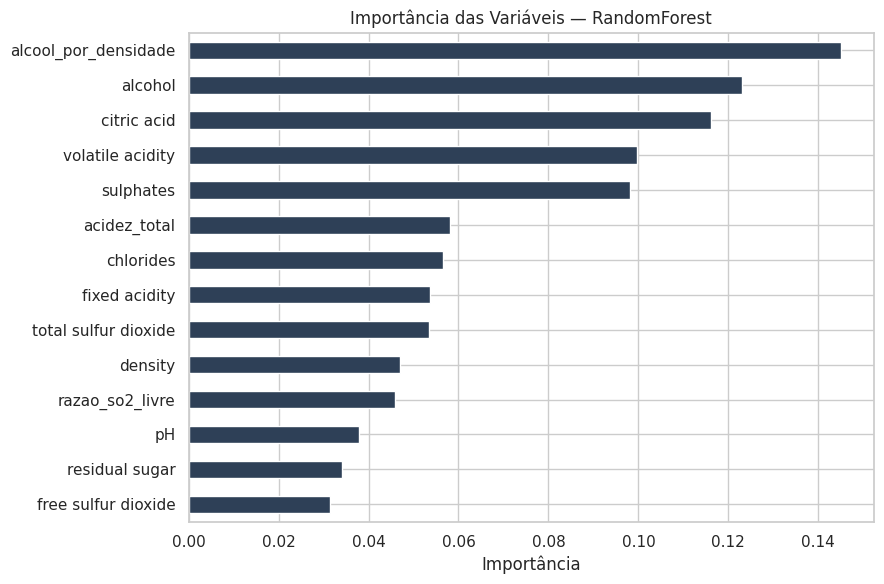

In [ ]:
def extrair_importancia(modelo, colunas):

    modelo_interno = (
        modelo.named_steps["modelo"]
        if hasattr(modelo, "named_steps")
        else modelo
    )

    if hasattr(modelo_interno, "feature_importances_"):
        return (
            pd.Series(
                modelo_interno.feature_importances_,
                index=colunas
            )
            .sort_values(ascending=False)
        )

    if hasattr(modelo_interno, "coef_"):
        return (
            pd.Series(
                modelo_interno.coef_[0],
                index=colunas
            )
            .sort_values(ascending=False)
        )

    return None


importancias = extrair_importancia(
    modelo_final,
    X.columns
)

print(importancias)

plt.figure(figsize=(9,6))

importancias.sort_values().plot(
    kind="barh",
    color="#2E4057"
)

plt.title(f"Importância das Variáveis — {melhor_modelo_nome}")
plt.xlabel("Importância")

plt.tight_layout()
plt.show()

### Discussão — implicações para o processo produtivo

A análise da importância das variáveis mostrou que o teor alcoólico foi a variável com maior contribuição para as previsões do modelo, indicando forte associação com a classificação de vinhos de alta qualidade. Em seguida, destacaram-se a acidez volátil, os sulfatos e o ácido cítrico, evidenciando que características relacionadas ao processo de fermentação e ao equilíbrio químico tem influência relevante na qualidade prevista.

As variáveis derivadas criadas durante a etapa de engenharia de atributos apresentaram menor contribuição, sugerindo que grande parte da informação já estava representada pelas variáveis originais.

É importante destacar que a importância das variáveis indica apenas sua contribuição para o desempenho do modelo preditivo. Esses resultados não estabelecem relações de causa e efeito, uma vez que fatores externos ao conjunto de dados também influenciam a qualidade do vinho.

Distribuição das classificações:

classificacao
comum                            140
potencialmente alta qualidade     21
alta qualidade                    11
Name: count, dtype: int64


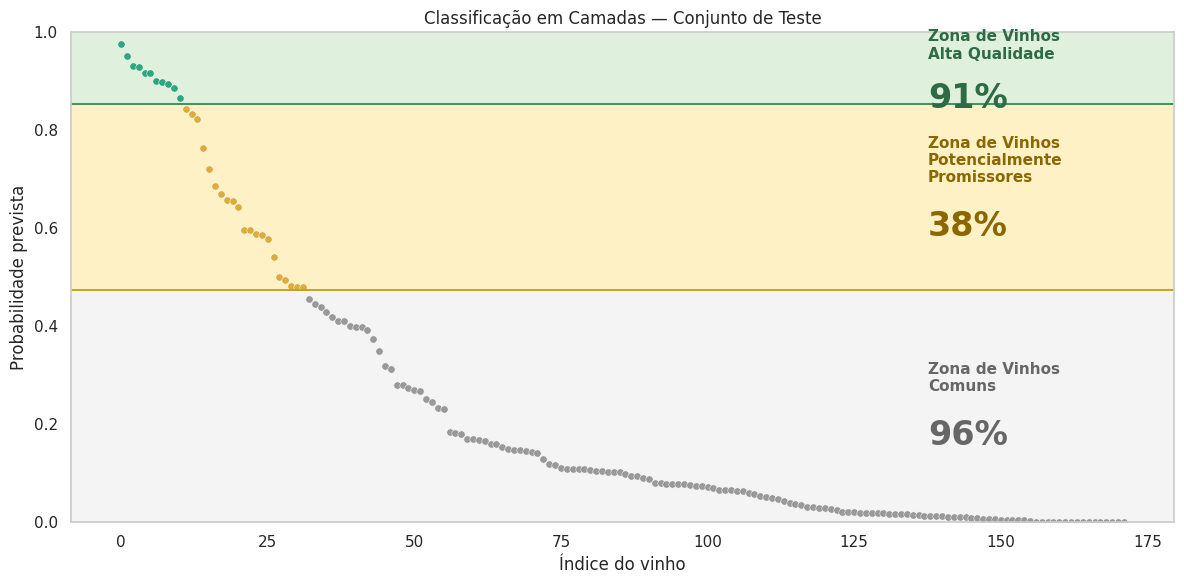

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,acidez_total,razao_so2_livre,alcool_por_densidade,probabilidade,classificacao,real
0,5.3,0.470,0.11,2.2,0.048,16.0,89.0,0.99182,3.54,0.88,13.6,5.770,0.179775,13.712166,0.975468,alta qualidade,1
1,11.6,0.410,0.54,1.5,0.095,22.0,41.0,0.99735,3.02,0.76,9.9,12.010,0.536585,9.926305,0.952060,alta qualidade,1
2,9.4,0.270,0.53,2.4,0.074,6.0,18.0,0.99620,3.20,1.13,12.0,9.670,0.333333,12.045774,0.931460,alta qualidade,1
3,8.7,0.330,0.38,3.3,0.063,10.0,19.0,0.99468,3.30,0.73,12.0,9.030,0.526316,12.064181,0.929675,alta qualidade,1
4,8.3,0.310,0.39,2.4,0.078,17.0,43.0,0.99444,3.31,0.77,12.5,8.610,0.395349,12.569889,0.917169,alta qualidade,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167,7.6,0.430,0.29,2.1,0.075,19.0,66.0,0.99718,3.40,0.64,9.5,8.030,0.287879,9.526866,0.000058,comum,0
168,7.6,0.645,0.03,1.9,0.086,14.0,57.0,0.99690,3.37,0.46,10.3,8.245,0.245614,10.332029,0.000000,comum,0
169,7.7,0.640,0.21,2.2,0.077,32.0,133.0,0.99560,3.27,0.45,9.9,8.340,0.240602,9.943753,0.000000,comum,0
170,6.7,0.675,0.07,2.4,0.089,17.0,82.0,0.99580,3.35,0.54,10.1,7.375,0.207317,10.142599,0.000000,comum,0


In [ ]:
import matplotlib.pyplot as plt

# Classificação dos vinhos

def classificar(probabilidade):
    if probabilidade >= limiar_alta:
        return "alta qualidade"
    elif probabilidade >= limiar_potencial:
        return "potencialmente alta qualidade"
    else:
        return "comum"

resultados = X_test.copy()

resultados["probabilidade"] = y_probs_test
resultados["classificacao"] = resultados["probabilidade"].apply(classificar)
resultados["real"] = y_test.values

resultados = (
    resultados
    .sort_values("probabilidade", ascending=False)
    .reset_index(drop=True)
)

# Cálculo dos percentuais por categoria

metricas = {}

for categoria in [
    "alta qualidade",
    "potencialmente alta qualidade",
    "comum"
]:

    subset = resultados[resultados["classificacao"] == categoria]

    total = len(subset)

    if categoria == "comum":
        acertos = (subset["real"] == 0).sum()
    else:
        acertos = (subset["real"] == 1).sum()

    percentual = 100 * acertos / total if total > 0 else 0

    metricas[categoria] = {
        "acertos": acertos,
        "total": total,
        "percentual": percentual
    }

print("Distribuição das classificações:\n")
print(resultados["classificacao"].value_counts())

# Gráfico

cores = {
    "alta qualidade": "#1B9E77",
    "potencialmente alta qualidade": "#D9A62E",
    "comum": "#8F8F8F"
}

plt.figure(figsize=(12, 6))

# Faixas

plt.axhspan(limiar_alta, 1, color="#DFF1DD")

plt.axhspan(
    limiar_potencial,
    limiar_alta,
    color="#FFF1C6"
)

plt.axhspan(
    0,
    limiar_potencial,
    color="#F4F4F4"
)

# Pontos

for categoria, cor in cores.items():

    mask = resultados["classificacao"] == categoria

    plt.scatter(
        resultados[mask].index,
        resultados[mask]["probabilidade"],
        color=cor,
        s=28,
        edgecolor="white",
        linewidth=0.4,
        alpha=0.9
    )

# Linhas dos limiares

plt.axhline(
    limiar_alta,
    color="#2E8B57",
    linewidth=1.3
)

plt.axhline(
    limiar_potencial,
    color="#C79B17",
    linewidth=1.3
)

# Textos das zonas

x = len(resultados) * 0.80

plt.text(
    x,
    (1 + limiar_alta) / 2 + 0.02,
    "Zona de Vinhos\nAlta Qualidade",
    fontsize=11,
    fontweight="bold",
    color="#2E6B45"
)

plt.text(
    x,
    (1 + limiar_alta) / 2 - 0.08,
    f"{metricas['alta qualidade']['percentual']:.0f}%",
    fontsize=24,
    fontweight="bold",
    color="#2E6B45"
)

plt.text(
    x,
    (limiar_alta + limiar_potencial) / 2 + 0.03,
    "Zona de Vinhos\nPotencialmente\nPromissores",
    fontsize=11,
    fontweight="bold",
    color="#8A6700"
)

plt.text(
    x,
    (limiar_alta + limiar_potencial) / 2 - 0.08,
    f"{metricas['potencialmente alta qualidade']['percentual']:.0f}%",
    fontsize=24,
    fontweight="bold",
    color="#8A6700"
)

plt.text(
    x,
    limiar_potencial / 2 + 0.03,
    "Zona de Vinhos\nComuns",
    fontsize=11,
    fontweight="bold",
    color="#666666"
)

plt.text(
    x,
    limiar_potencial / 2 - 0.08,
    f"{metricas['comum']['percentual']:.0f}%",
    fontsize=24,
    fontweight="bold",
    color="#666666"
)

plt.xlabel("Índice do vinho")
plt.ylabel("Probabilidade prevista")
plt.title("Classificação em Camadas — Conjunto de Teste")

plt.ylim(0, 1)
plt.grid(alpha=0.15)

plt.tight_layout()
plt.show()

resultados